# Video Game Sales Exercise

Video Games Dataset https://www.kaggle.com/datasets/gregorut/videogamesales?resource=download

In [144]:
import numpy as np
import pandas as pd

In [145]:
df = pd.read_csv('vgsales.csv')
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [162]:
df.shape

(16598, 11)

In [ ]:
# try reading file using np.genfromtxt but hit error, convert df to records instead
# arr = np.genfromtxt('vgsales.csv', delimiter=',', dtype=None, encoding='utf-8', names=True)
recarr = df.to_records(index=False)
recarr

rec.array([(    1, 'Wii Sports', 'Wii', 2006., 'Sports', 'Nintendo', 4.149e+01, 2.902e+01, 3.77, 8.46, 8.274e+01),
           (    2, 'Super Mario Bros.', 'NES', 1985., 'Platform', 'Nintendo', 2.908e+01, 3.580e+00, 6.81, 0.77, 4.024e+01),
           (    3, 'Mario Kart Wii', 'Wii', 2008., 'Racing', 'Nintendo', 1.585e+01, 1.288e+01, 3.79, 3.31, 3.582e+01),
           ...,
           (16598, 'SCORE International Baja 1000: The Official Game', 'PS2', 2008., 'Racing', 'Activision', 0.000e+00, 0.000e+00, 0.  , 0.  , 1.000e-02),
           (16599, 'Know How 2', 'DS', 2010., 'Puzzle', '7G//AMES', 0.000e+00, 1.000e-02, 0.  , 0.  , 1.000e-02),
           (16600, 'Spirits & Spells', 'GBA', 2003., 'Platform', 'Wanadoo', 1.000e-02, 0.000e+00, 0.  , 0.  , 1.000e-02)],
          dtype=[('Rank', '<i8'), ('Name', 'O'), ('Platform', 'O'), ('Year', '<f8'), ('Genre', 'O'), ('Publisher', 'O'), ('NA_Sales', '<f8'), ('EU_Sales', '<f8'), ('JP_Sales', '<f8'), ('Other_Sales', '<f8'), ('Global_Sales', '<f8')])

In [163]:
recarr.shape

(16598,)

In [164]:
# name field with "," causes extra field and error when using np.genfromtxt
df[943:944]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
943,945,"Hey You, Pikachu!",N64,1998.0,Simulation,Nintendo,0.83,0.06,0.93,0.0,1.83


### 1. Which 5 games have the highest global sales? What do they have in common?

**Answer:** 5 games as followed, they are all published by Nintendo


In [165]:
df.sort_values('Global_Sales', ascending=False).head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [149]:
# faster option
df.nlargest(5, 'Global_Sales')

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [150]:
# using numpy
np.sort(recarr, order='Global_Sales')[::-1][:5]

rec.array([(1, 'Wii Sports', 'Wii', 2006., 'Sports', 'Nintendo', 41.49, 29.02,  3.77, 8.46, 82.74),
           (2, 'Super Mario Bros.', 'NES', 1985., 'Platform', 'Nintendo', 29.08,  3.58,  6.81, 0.77, 40.24),
           (3, 'Mario Kart Wii', 'Wii', 2008., 'Racing', 'Nintendo', 15.85, 12.88,  3.79, 3.31, 35.82),
           (4, 'Wii Sports Resort', 'Wii', 2009., 'Sports', 'Nintendo', 15.75, 11.01,  3.28, 2.96, 33.  ),
           (5, 'Pokemon Red/Pokemon Blue', 'GB', 1996., 'Role-Playing', 'Nintendo', 11.27,  8.89, 10.22, 1.  , 31.37)],
          dtype=[('Rank', '<i8'), ('Name', 'O'), ('Platform', 'O'), ('Year', '<f8'), ('Genre', 'O'), ('Publisher', 'O'), ('NA_Sales', '<f8'), ('EU_Sales', '<f8'), ('JP_Sales', '<f8'), ('Other_Sales', '<f8'), ('Global_Sales', '<f8')])

### 2. Calculate total sales by genre. Which genre generates the most revenue globally?

**Answer:** Action

In [151]:
# all possible options
df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).reset_index()
df.groupby('Genre', as_index=False)['Global_Sales'].sum().sort_values('Global_Sales', ascending=False)
df.groupby('Genre', as_index=False).agg({ 'Global_Sales': 'sum' }).sort_values('Global_Sales', ascending=False)

,Genre,Global_Sales
0,Action,1751.18
10,Sports,1330.93
8,Shooter,1037.37
7,Role-Playing,927.37
4,Platform,831.37
3,Misc,809.96
6,Racing,732.04
2,Fighting,448.91
9,Simulation,392.20
5,Puzzle,244.95


### 3. Find the average sales per game for each platform. Which platforms have the highest average?
GB has the highest average

In [152]:
df.groupby('Platform', as_index=False)['Global_Sales'].mean().round(2).sort_values('Global_Sales',ascending=False).head(10)


,Platform,Global_Sales
5,GB,2.61
11,NES,2.56
8,GEN,1.05
23,SNES,0.84
18,PS4,0.83
28,X360,0.77
0,2600,0.73
17,PS3,0.72
26,Wii,0.70
10,N64,0.69


### 4. Which publisher has released the most games? Do they also have the highest total sales?

Electronic Arts	releases the most games but Nintendo has to highest total sales

In [153]:
print("Top 15 publishers by no. of games")
top_publisher = (
     df.groupby('Publisher', as_index=False)
     .agg(num_games=('Name','size'),
          total_global_sales=('Global_Sales','sum'))
     .sort_values('num_games', ascending=False).head(15))
top_publisher

Top 15 publishers by no. of games


,Publisher,num_games,total_global_sales
138,Electronic Arts,1351,1110.32
21,Activision,975,727.46
347,Namco Bandai Games,932,254.09
525,Ubisoft,921,474.72
275,Konami Digital Entertainment,832,283.64
488,THQ,715,340.77
359,Nintendo,703,1786.56
456,Sony Computer Entertainment,683,607.50
446,Sega,639,272.99
494,Take-Two Interactive,413,399.54


In [113]:
most_games = top_publisher.loc[top_publisher['num_games'].idxmax()]
print(f"Publisher with Most Game Releases:  {most_games.Publisher} — {most_games.num_games} games released")

Publisher with Most Game Releases:  Electronic Arts — 1351 games released


In [112]:
most_sales = top_publisher.loc[top_publisher['total_global_sales'].idxmax()]
print(f"Publisher with Highest Total Global Sales: {most_sales.Publisher} — {most_sales.total_global_sales} USD(m)")

Publisher with Highest Total Global Sales: Nintendo — 1786.56 USD(m)


### 5. For games released after 2010, which genre dominated each region (NA, EU, JP)?

In [119]:
print("Total Sales by Region (2010++):")
total_by_region = (df.loc[df['Year'] > 2010].groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum())
total_by_region

Total Sales by Region (2010++):


,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,227.46,200.52,62.15
Adventure,14.34,13.85,11.84
Fighting,31.49,16.65,12.24
Misc,70.29,40.88,17.25
Platform,38.31,30.14,12.07
Puzzle,2.84,3.58,2.91
Racing,31.36,41.00,5.61
Role-Playing,79.02,60.06,76.77
Shooter,184.53,142.54,11.42


In [120]:
print("Top Genre by Region (2010++):")
total_by_region = total_by_region.rename(columns={
    'NA_Sales': 'North America',
    'EU_Sales': 'Europe',
    'JP_Sales': 'Japan'
})
total_by_region.idxmax()


Top Genre by Region (2010++):


North America          Action
Europe                 Action
Japan            Role-Playing
dtype: object

### 6. Calculate the percentage of global sales that each region contributes. Which region is most important?

In [ ]:
# 1. Get total sales of each of the columns in the dataframe, returns totals series
totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
totals

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

In [ ]:
# 2. Get global total sales by suming totals series
global_total = totals.sum()

In [ ]:
# 3. Create pct series by using totals and global_total series
pct_of_sales = (totals / global_total * 100).round(2)
pct_of_sales

NA_Sales       49.27
EU_Sales       27.30
JP_Sales       14.48
Other_Sales     8.95
dtype: float64

In [ ]:
# 4. Create dataframe from totals and pct_of_sales series
print('Region Sales & as % of Global Sales:')
region_sales_df = pd.DataFrame({
    'Sales': totals,
    '% of Global': pct_of_sales
}).sort_values('% of Global', ascending=False)
region_sales_df

Region Sales & as % of Global Sales:


,Sales,% of Global
NA_Sales,4392.95,49.27
EU_Sales,2434.13,27.30
JP_Sales,1291.02,14.48
Other_Sales,797.75,8.95


In [ ]:
# 5. Transpose the dataframe
print('Region Sales & as % of Global Sales:')
region_sales_df.T

Region Sales & as % of Global Sales:


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Sales,4392.95,2434.13,1291.02,797.75
% of Global,49.27,27.30,14.48,8.95


### 7. Find games where Japanese sales exceed North American sales. What patterns do you notice about genre or publisher?

In [ ]:
# Create jp_na_comp dataframe where JP sales > NA sales, return df with selected columns
jp_na_comp = df.loc[df['JP_Sales'] > df['NA_Sales'], ['Name', 'Genre', 'Platform', 'Publisher', 'JP_Sales', 'NA_Sales', 'Global_Sales']]

# Add the difference column
jp_na_comp['Diff'] = (jp_na_comp['JP_Sales'] - jp_na_comp['NA_Sales']).round(2)

# Sort by JP_Sales descending and show top 15
jp_na_comp.sort_values('JP_Sales', ascending=False).head(15)


,Name,Genre,Platform,Publisher,JP_Sales,NA_Sales,Global_Sales,Diff
26,Pokemon Black/Pokemon White,Role-Playing,DS,Nintendo,5.65,5.57,15.32,0.08
41,Animal Crossing: Wild World,Simulation,DS,Nintendo,5.33,2.55,12.27,2.78
27,Brain Age 2: More Training in Minutes a Day,Puzzle,DS,Nintendo,5.32,3.44,15.30,1.88
214,Monster Hunter Freedom 3,Role-Playing,PSP,Capcom,4.87,0.00,4.87,4.87
73,Animal Crossing: New Leaf,Simulation,3DS,Nintendo,4.36,2.01,9.09,2.35
149,Dragon Quest IX: Sentinels of the Starry Skies,Role-Playing,DS,Nintendo,4.35,0.66,5.84,3.69
161,Monster Hunter Freedom Unite,Role-Playing,PSP,Capcom,4.13,0.47,5.50,3.66
242,Dragon Quest VII: Warriors of Eden,Role-Playing,PS,Enix Corporation,4.10,0.20,4.47,3.90
76,Super Mario Kart,Racing,SNES,Nintendo,3.81,3.54,8.76,0.27
312,Dragon Warrior III,Role-Playing,NES,Enix Corporation,3.77,0.10,3.87,3.67


In [161]:
# get a count of games by Genre where JP sales > NA sales
print("Game count by Genre where JP > NA:")
jp_na_comp.groupby('Genre')['Name'].count().sort_values(ascending=False).rename('No. of games').reset_index()

Game count by Genre where JP > NA:


,Genre,No. of games
0,Role-Playing,772
1,Action,684
2,Adventure,675
3,Misc,450
4,Sports,427
5,Fighting,301
6,Strategy,232
7,Simulation,201
8,Shooter,107
9,Puzzle,104


In [ ]:
# get a count of games by Publisher where JP sales > NA sales
print("Game count by Publisher where JP > NA:")
jp_na_comp.groupby('Publisher')['Name'].count().sort_values(ascending=False).rename('No. of games').reset_index().head(15)

Game count by Publisher where JP > NA:


,Publisher,No. of games
0,Namco Bandai Games,636
1,Konami Digital Entertainment,395
2,Nintendo,286
3,Sega,276
4,Tecmo Koei,233
5,Sony Computer Entertainment,160
6,Capcom,141
7,Idea Factory,120
8,Square Enix,105
9,D3Publisher,83


### Genre-Region Heatmap - Build a heatmap showing the preference intensity for each genre across the four regions. Normalize by region (so each region sums to 100%) to see relative preferences rather than absolute sales.

In [156]:
# 1️) Aggregate total sales by Genre and for each Region
print("Total Sales by Region:")
total_by_region = (df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum())
total_by_region

Total Sales by Region:


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Adventure,105.80,64.13,52.07,16.81
Fighting,223.59,101.32,87.35,36.68
Misc,410.24,215.98,107.76,75.32
Platform,447.05,201.63,130.77,51.59
Puzzle,123.78,50.78,57.31,12.55
Racing,359.42,238.39,56.69,77.27
Role-Playing,327.28,188.06,352.31,59.61
Shooter,582.60,313.27,38.28,102.69


In [157]:
# 2) Normalize by region (each column sums to 100%)
total_by_region_norm = total_by_region.div(total_by_region.sum(axis=0), axis=1) * 100
total_by_region_norm = total_by_region_norm.round(2)

print("Normalized Total Sales by Region (% of regional sales):")
total_by_region_norm

Normalized Total Sales by Region (% of regional sales):


,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,19.98,21.57,12.39,23.49
Adventure,2.41,2.63,4.03,2.11
Fighting,5.09,4.16,6.77,4.60
Misc,9.34,8.87,8.35,9.44
Platform,10.18,8.28,10.13,6.47
Puzzle,2.82,2.09,4.44,1.57
Racing,8.18,9.79,4.39,9.69
Role-Playing,7.45,7.73,27.29,7.47
Shooter,13.26,12.87,2.97,12.87


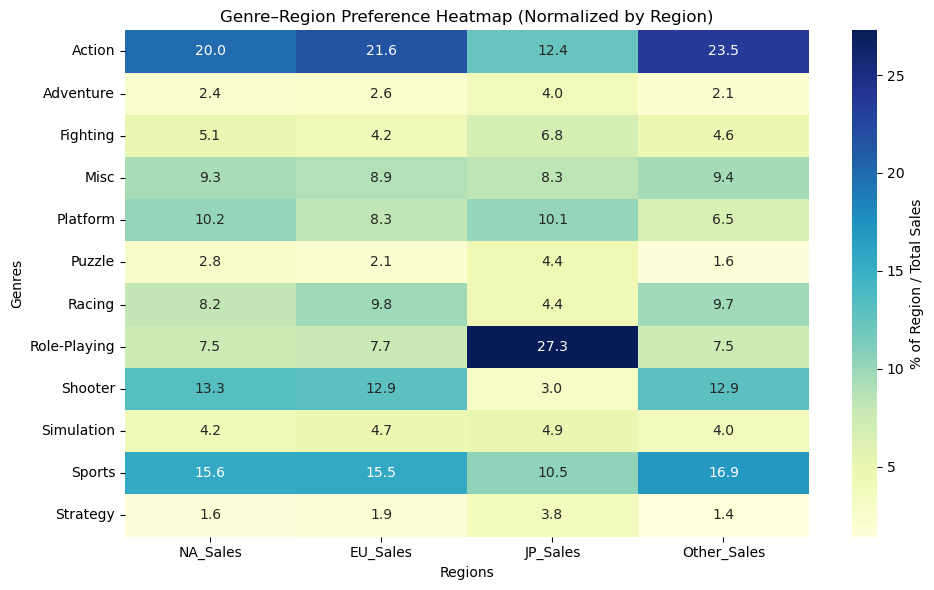

In [ ]:
# 3) Plot the heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    total_by_region_norm,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% of Region / Total Sales'}
)

plt.title('Genre–Region Preference Heatmap (Normalized by Region)')
plt.ylabel('Genres')
plt.xlabel('Regions')
plt.tight_layout()
plt.show()
